In [416]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Exploratory Data Analysis

In [419]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

In [421]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [423]:
train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [425]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [427]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [429]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Handling missing values

In [432]:
train.drop(columns='Cabin', inplace=True)
test.drop(columns='Cabin', inplace=True)

In [434]:
train['Age'].fillna(train['Age'].mean(), inplace=True)
test['Age'].fillna(test['Age'].mean(), inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13172\832606015.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].mean(), inplace=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13172\832606015.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [436]:
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)
test['Embarked'].fillna(test['Embarked'].mode()[0], inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13172\2166674729.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13172\2166674729.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as

In [438]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [440]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [442]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

## Visualizing data

In [445]:
def visualize_cat_variable(data, col, hue=None, title=None):
    sns.countplot(data, x=col, hue=hue)
    plt.title(title)
    plt.show()

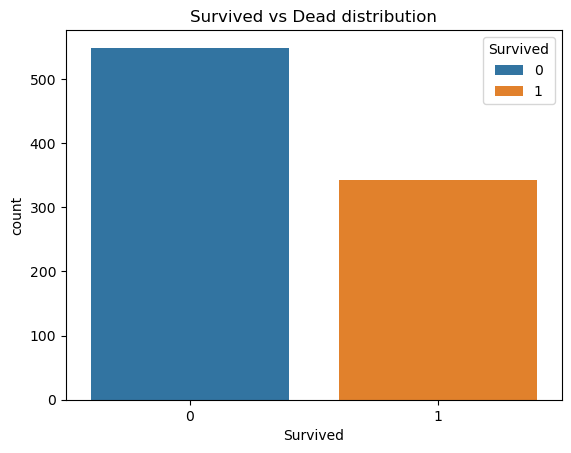

In [447]:
visualize_cat_variable(train, 'Survived', 'Survived', 'Survived vs Dead distribution')

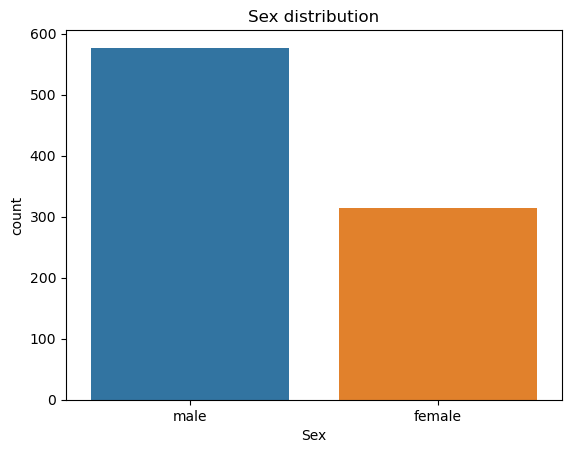

In [449]:
visualize_cat_variable(train, 'Sex', 'Sex', 'Sex distribution')

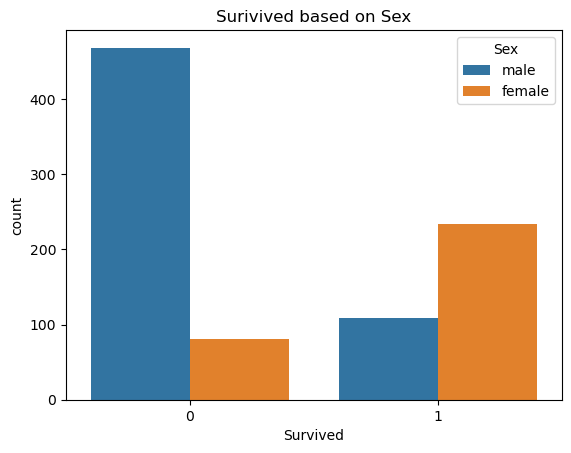

In [451]:
visualize_cat_variable(train, 'Survived', 'Sex', 'Surivived based on Sex')

Tỉ lệ nam chết so với nữ gần như gấp 6 lần, còn tỉ lệ nam sống so với nữ chỉ gần bằng 0.5.

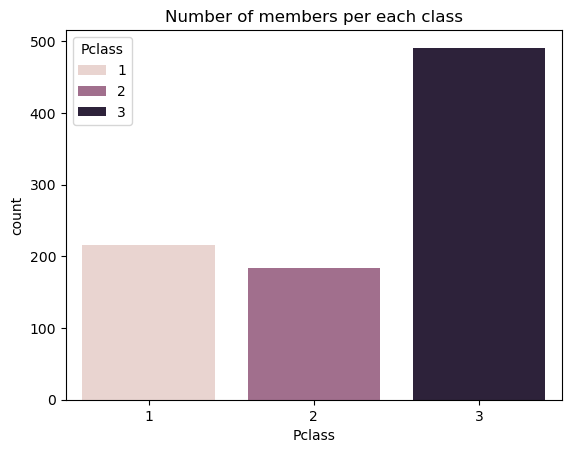

In [454]:
visualize_cat_variable(train, 'Pclass', 'Pclass', 'Number of members per each class')

Ta sẽ thấy tỉ lệ sống sót ở Pclass = 1 là cao hơn.

In [457]:
survived_df = train[train['Survived'] == 1]
dead_df = train[train['Survived'] == 0]

Text(0.5, 1.0, 'Dataset Age distribution')

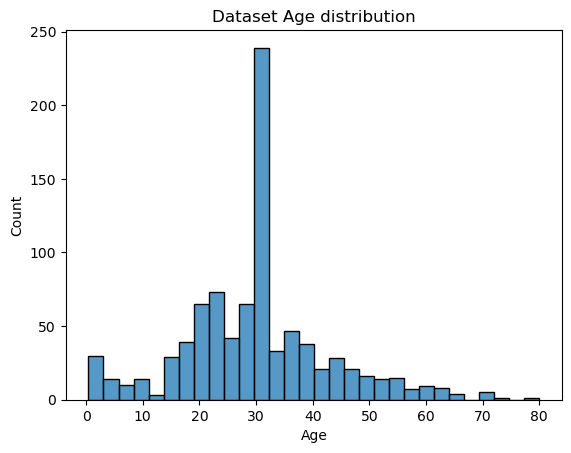

In [459]:
sns.histplot(data=train, x='Age')
plt.title('Dataset Age distribution')

Text(0.5, 1.0, 'Dead Age distribution')

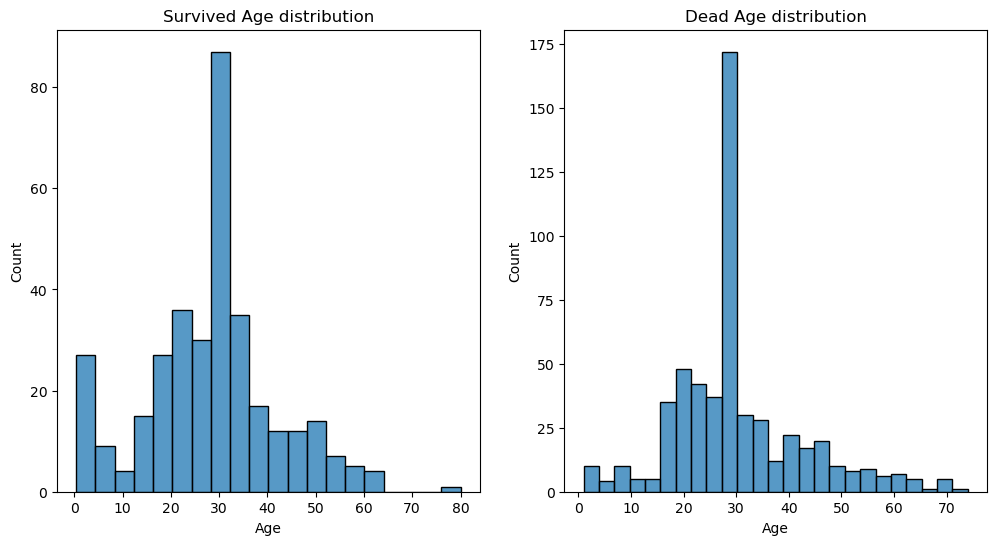

In [461]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

sns.histplot(data=survived_df, x='Age', ax=axs[0])
axs[0].set_title('Survived Age distribution')

sns.histplot(data=dead_df, x='Age', ax=axs[1])
axs[1].set_title('Dead Age distribution')

Ta thấy phân bố về tuổi của cả 3 dataset là khá tương đồng.

Text(0.5, 1.0, 'Dead members by class and gender')

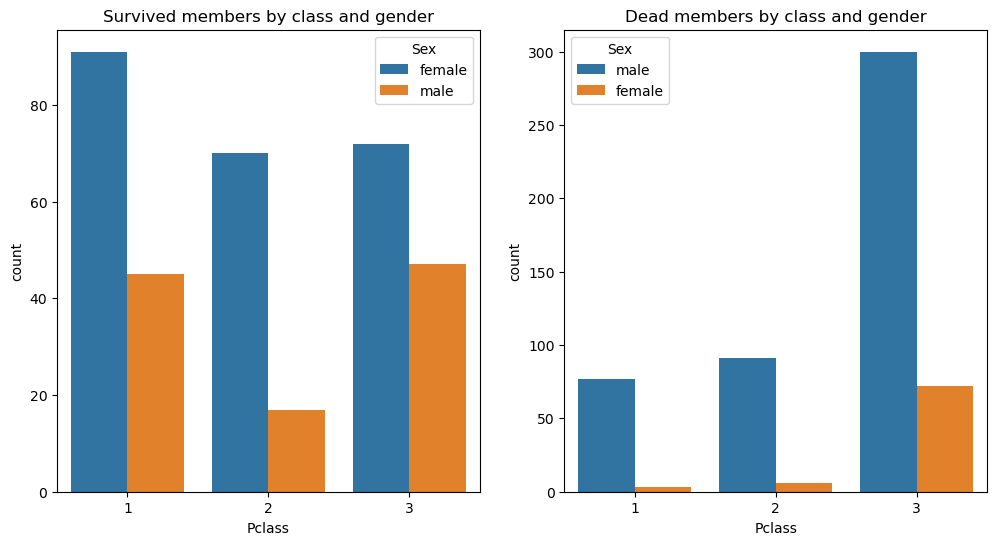

In [463]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.countplot(survived_df, x='Pclass', hue='Sex', ax=ax[0])
ax[0].set_title('Survived members by class and gender')
sns.countplot(dead_df, x='Pclass', hue='Sex', ax=ax[1])
ax[1].set_title('Dead members by class and gender')

Text(0.5, 0, 'Fare')

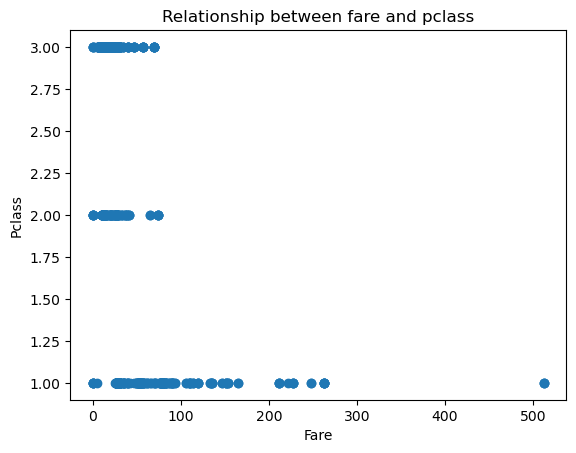

In [465]:
plt.scatter(train['Fare'], train['Pclass'])
plt.title('Relationship between fare and pclass')
plt.ylabel('Pclass')
plt.xlabel('Fare')

Ta thấy giá vé càng cao thì càng có khả năng được ngồi ở Pclass = 1.

<Axes: >

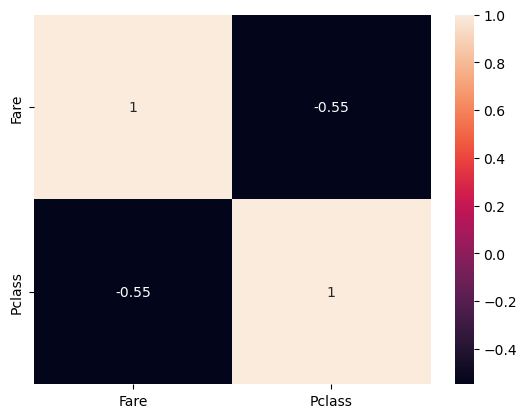

In [469]:
sns.heatmap(train[['Fare', 'Pclass']].corr(), annot=True)

Ta thấy có sự tương quan giữa giá vé và Pclass.

In [472]:
numerical_df = train.select_dtypes(include=[np.number])
numerical_df.drop(columns='PassengerId', inplace=True)

<Axes: >

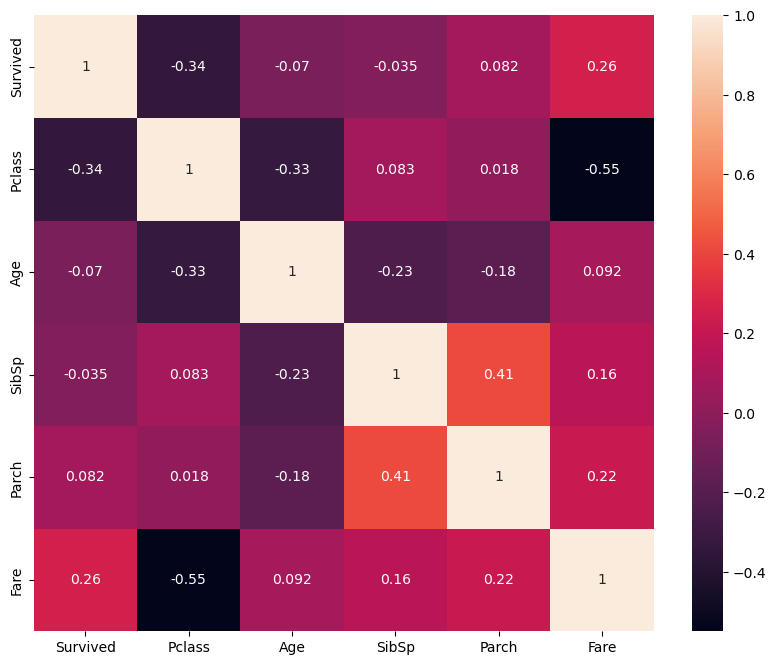

In [474]:
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True)

Ta thấy có một mối tương quan nhẹ giữa Survived và Fare, ta thấy hợp lí do giá vé càng cao thì PClass càng cao cấp, do đó tỉ lệ sống sót cũng cao hơn.

In [477]:
train.drop(columns=['PassengerId', 'Name', 'Ticket', 'Embarked', 'Parch', 'SibSp'], inplace=True)
test.drop(columns=['PassengerId', 'Name', 'Ticket', 'Embarked', 'Parch', 'SibSp'], inplace=True)

In [479]:
train

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.000000,7.2500
1,1,1,female,38.000000,71.2833
2,1,3,female,26.000000,7.9250
3,1,1,female,35.000000,53.1000
4,0,3,male,35.000000,8.0500
...,...,...,...,...,...
886,0,2,male,27.000000,13.0000
887,1,1,female,19.000000,30.0000
888,0,3,female,29.699118,23.4500
889,1,1,male,26.000000,30.0000


In [579]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_sex = ohe.fit_transform(train[['Sex']])
X_test_sex = ohe.fit_transform(test[['Sex']])

X_train_pclass = ohe.fit_transform(train[['Pclass']])
X_test_pclass = ohe.fit_transform(test[['Pclass']])

In [581]:
X_train_transformed = np.concatenate((train.drop(columns=['Sex', 'Pclass']), X_train_sex, X_train_pclass), axis=1)
X_test_transformed = np.concatenate((test.drop(columns=['Sex', 'Pclass']), X_test_sex, X_test_pclass), axis=1)

In [583]:
pd.DataFrame(X_train_transformed)

,0,1,2,3,4,5,6,7
0,0.0,22.000000,7.2500,0.0,1.0,0.0,0.0,1.0
1,1.0,38.000000,71.2833,1.0,0.0,1.0,0.0,0.0
2,1.0,26.000000,7.9250,1.0,0.0,0.0,0.0,1.0
3,1.0,35.000000,53.1000,1.0,0.0,1.0,0.0,0.0
4,0.0,35.000000,8.0500,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
886,0.0,27.000000,13.0000,0.0,1.0,0.0,1.0,0.0
887,1.0,19.000000,30.0000,1.0,0.0,1.0,0.0,0.0
888,0.0,29.699118,23.4500,1.0,0.0,0.0,0.0,1.0
889,1.0,26.000000,30.0000,0.0,1.0,1.0,0.0,0.0


In [585]:
y_train = X_train_transformed[:, 0]
y_train

array([0., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 1., 0.,
       1., 0., 1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0.,
       0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0.,
       0., 1., 1., 0., 1., 1., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0.,
       1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 1.,
       1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0.,
       0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 1., 0., 0.,
       1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1.,
       1., 0., 0., 1., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
       1., 0., 0., 1., 1., 1., 0., 1., 0., 0., 0., 1., 1., 0., 1., 0., 1.,
       0., 0., 0., 1., 0.

In [587]:
X_train_transformed = X_train_transformed[:, 1:]

In [589]:
pd.DataFrame(X_train_transformed)

,0,1,2,3,4,5,6
0,22.000000,7.2500,0.0,1.0,0.0,0.0,1.0
1,38.000000,71.2833,1.0,0.0,1.0,0.0,0.0
2,26.000000,7.9250,1.0,0.0,0.0,0.0,1.0
3,35.000000,53.1000,1.0,0.0,1.0,0.0,0.0
4,35.000000,8.0500,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...
886,27.000000,13.0000,0.0,1.0,0.0,1.0,0.0
887,19.000000,30.0000,1.0,0.0,1.0,0.0,0.0
888,29.699118,23.4500,1.0,0.0,0.0,0.0,1.0
889,26.000000,30.0000,0.0,1.0,1.0,0.0,0.0


# Training models

In [636]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

In [638]:
lg_clf = LogisticRegression()
lg_clf_param = {'penalty':['11','l2','elasticnet'], 'C':range(1, 10)}

svm_clf = SVC()
svm_clf_param = {'C':range(1, 10), 'kernel':['rbf', 'poly']}

nb_clf = MultinomialNB()
nb_clf_param = {'alpha':range(10)}

knn_clf = KNeighborsClassifier()
knn_clf_param = {'n_neighbors':range(1, 10)}

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

## Logistic Regression

In [641]:
search = GridSearchCV(estimator=lg_clf, param_grid=lg_clf_param, cv=kfold)
search.fit(X_train_transformed, y_train)
search.best_params_

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

{'C': 9, 'penalty': 'l2'}

In [670]:
lg_clf = LogisticRegression()
lg_clf.fit(X_train_transformed, y_train)

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [672]:
lg_clf.score(X_train_transformed, y_train)

0.797979797979798

## Support Vector Machines

In [646]:
search = GridSearchCV(estimator=svm_clf, param_grid=svm_clf_param, cv=kfold)
search.fit(X_train_transformed, y_train)
search.best_params_

{'C': 9, 'kernel': 'rbf'}

In [676]:
svm_clf = SVC(C=9, kernel='rbf')
svm_clf.fit(X_train_transformed, y_train)

SVC(C=9)

In [678]:
svm_clf.score(X_train_transformed, y_train)

0.7138047138047138

## Multinomial Naive Bayes

In [649]:
search = GridSearchCV(estimator=nb_clf, param_grid=nb_clf_param, cv=kfold)
search.fit(X_train_transformed, y_train)
search.best_params_

{'alpha': 0}

In [680]:
nb_clf = MultinomialNB()
nb_clf.fit(X_train_transformed, y_train)

MultinomialNB()

In [682]:
nb_clf.score(X_train_transformed, y_train)

0.6936026936026936

## XGBoost

In [698]:
xgb_clf = XGBClassifier()
xgb_clf.fit(X_train_transformed, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [700]:
xgb_clf.score(X_train_transformed, y_train)

0.9506172839506173

## Voting Classifier

In [704]:
from sklearn.ensemble import VotingClassifier

models = [
    ('logreg', lg_clf),
    ('svc', SVC(probability=True, C=9, kernel='rbf')),
    ('naive', nb_clf),
    ('xgboost', xgb_clf)
]

voting_model = VotingClassifier(estimators=models, voting='soft')
voting_model.fit(X_train_transformed, y_train)

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VotingClassifier(estimators=[('logreg', LogisticRegression()),
                             ('svc', SVC(C=9, probability=True)),
                             ('naive', MultinomialNB()),
                             ('xgboost',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_type...
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=None, ...))],
                 voting='soft')

In [706]:
voting_model.score(X_train_transformed, y_train)

0.8125701459034792

In [708]:
cross_val_score(voting_model, X_train_transformed, y_train, cv=kfold)

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

array([0.77777778, 0.82022472, 0.76404494, 0.78651685, 0.73033708,
       0.79775281, 0.7752809 , 0.75280899, 0.73033708, 0.73033708])

In [716]:
y_pred = xgb_clf.predict(X_test_transformed)
y_pred

array([0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [742]:
submit = pd.DataFrame()
submit['PassengerId'] = pd.read_csv('data/test.csv')['PassengerId']
submit['Survived'] = y_pred

In [744]:
submit

,PassengerId,Survived
0,892,0
1,893,0
2,894,1
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [746]:
submit.to_csv('gender_submission.csv', index=False)